# Student Exam Score Predictor

**COMP6577001 Machine Learning, Final Project. Group 8 (LA84), BINUS University.**

| Name | Student ID |
|---|---|
| Chris Toper Jasson Hartanto | 2902557990 |
| Frey Reinhardt Thio | 2902575255 |
| Renata Lie | 2902555663 |
| Yonathan Amadeo Hardy | 2902591706 |
| Jason Kenneth Lay | 2902575330 |

## 1. Why we built this

## Setup and imports

In [34]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.model_selection import (
    KFold, RandomizedSearchCV, cross_val_score, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
)
from sklearn.svm import SVR

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path("artifacts")
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. The data

In [35]:
df = pd.read_csv("StudentPerformanceFactors.csv")
print(f"Shape: {df.shape}")
print(f"Total siswa: {len(df):,}")
print(f"Total fitur: {df.shape[1] - 1} (excluding target)")
df.head()

Shape: (6607, 20)
Total siswa: 6,607
Total fitur: 19 (excluding target)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [37]:
df.describe().round(2)

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00,6607.00
mean,19.98,79.98,7.03,75.07,1.49,2.97,67.24
std,5.99,11.55,1.47,14.40,1.23,1.03,3.89
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


## 3. Exploring the data

### 3.1 Missing values

In [38]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_count", ascending=False)
print("Kolom dengan missing values:")
print(missing_df)
print(f"\nTotal missing: {missing.sum()} ({missing.sum() / df.size * 100:.3f}% dari seluruh data)")

Kolom dengan missing values:
                          missing_count  missing_pct
Parental_Education_Level             90         1.36
Teacher_Quality                      78         1.18
Distance_from_Home                   67         1.01

Total missing: 235 (0.178% dari seluruh data)


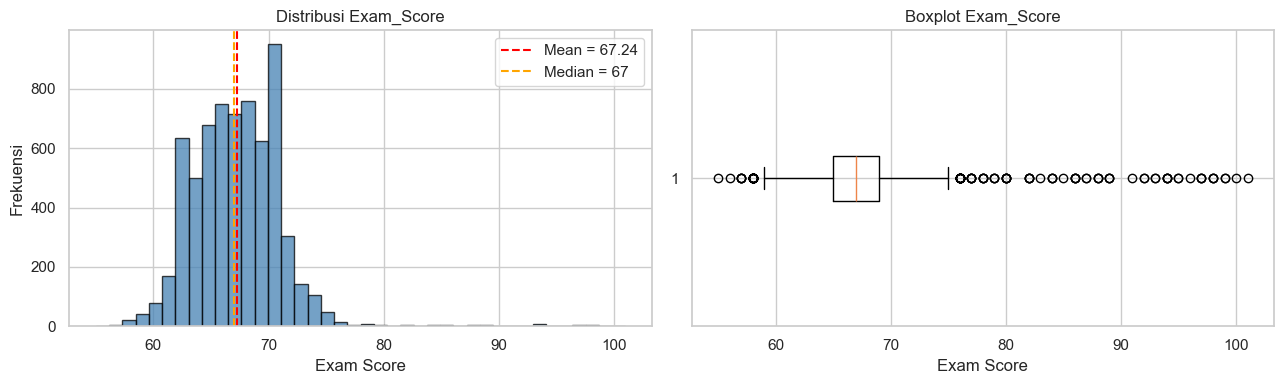


Skewness: 1.645
Kurtosis: 10.575
Outlier (>100): 1 baris


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["Exam_Score"], bins=40, edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(df["Exam_Score"].mean(), color="red", linestyle="--", label=f"Mean = {df['Exam_Score'].mean():.2f}")
axes[0].axvline(df["Exam_Score"].median(), color="orange", linestyle="--", label=f"Median = {df['Exam_Score'].median():.0f}")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Frekuensi")
axes[0].set_title("Distribusi Exam_Score")
axes[0].legend()

axes[1].boxplot(df["Exam_Score"], vert=False)
axes[1].set_xlabel("Exam Score")
axes[1].set_title("Boxplot Exam_Score")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png", bbox_inches="tight")
plt.show()

print(f"\nSkewness: {df['Exam_Score'].skew():.3f}")
print(f"Kurtosis: {df['Exam_Score'].kurtosis():.3f}")
print(f"Outlier (>100): {(df['Exam_Score'] > 100).sum()} baris")

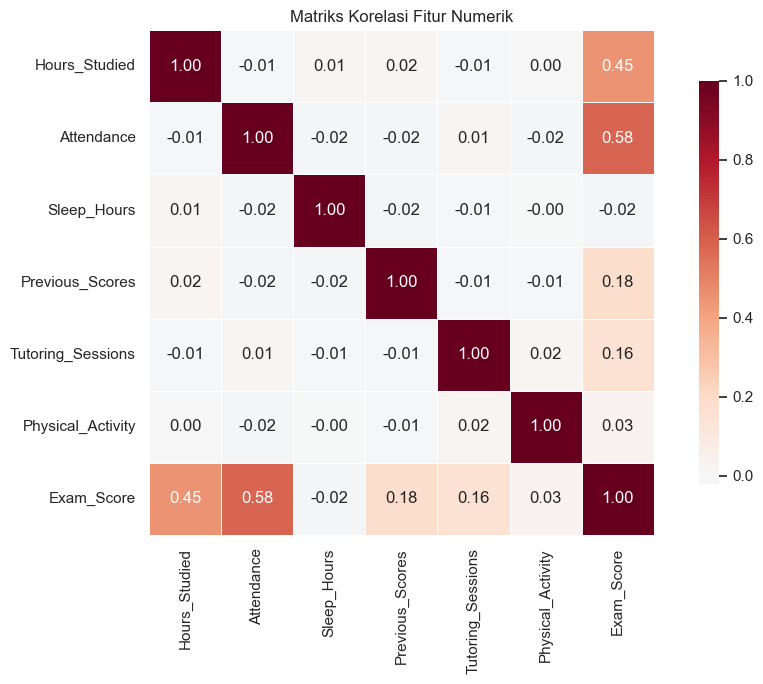


Korelasi fitur numerik dengan Exam_Score (sorted):
Attendance           0.581
Hours_Studied        0.445
Previous_Scores      0.175
Tutoring_Sessions    0.157
Physical_Activity    0.028
Sleep_Hours         -0.017
Name: Exam_Score, dtype: float64


In [40]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriks Korelasi Fitur Numerik")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("\nKorelasi fitur numerik dengan Exam_Score (sorted):")
target_corr = corr_matrix["Exam_Score"].drop("Exam_Score").sort_values(ascending=False)
print(target_corr.round(3))

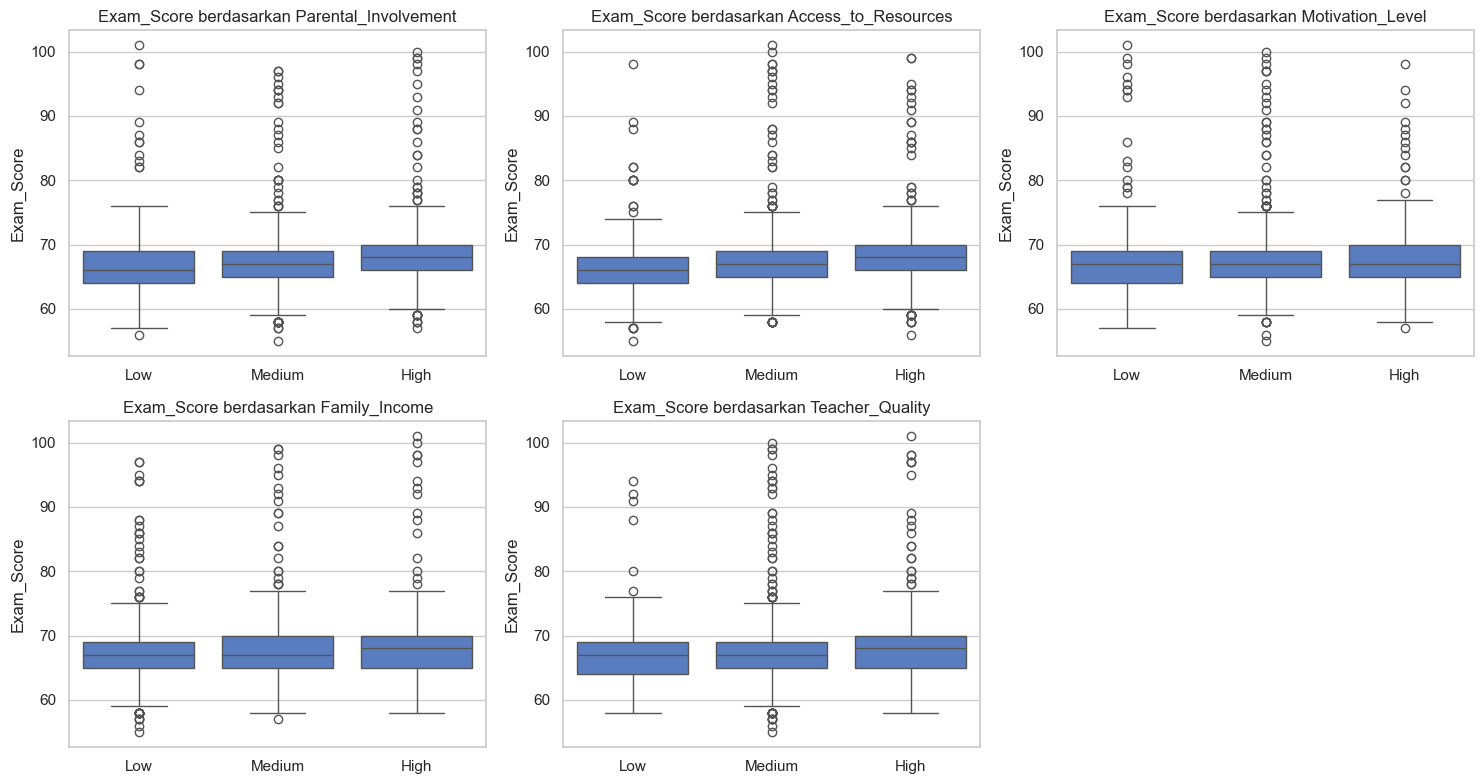

In [41]:
ordinal_cols_eda = ["Parental_Involvement", "Access_to_Resources", "Motivation_Level",
                    "Family_Income", "Teacher_Quality"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(ordinal_cols_eda):
    order = ["Low", "Medium", "High"]
    sns.boxplot(data=df, x=col, y="Exam_Score", order=order, ax=axes[idx])
    axes[idx].set_title(f"Exam_Score berdasarkan {col}")
    axes[idx].set_xlabel("")

axes[5].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_ordinal_features.png", bbox_inches="tight")
plt.show()

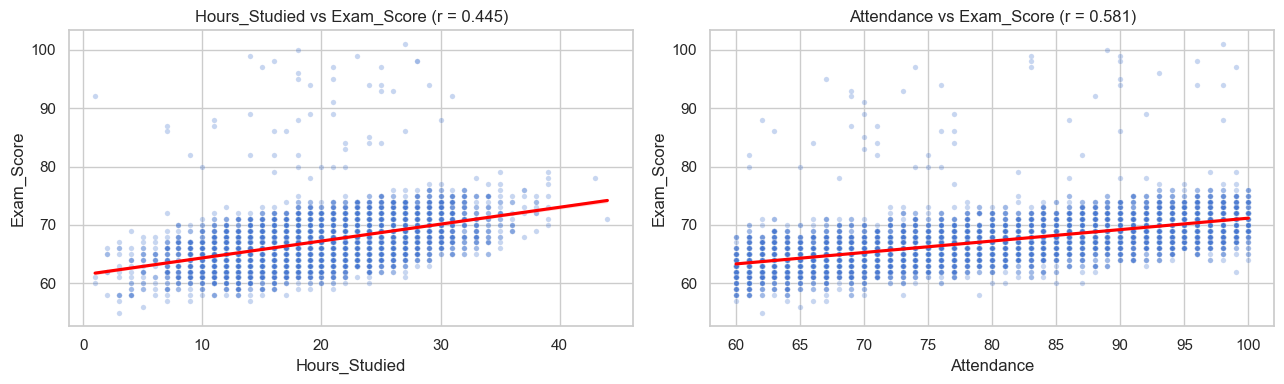

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.scatterplot(data=df, x="Hours_Studied", y="Exam_Score", alpha=0.3, ax=axes[0], s=15)
sns.regplot(data=df, x="Hours_Studied", y="Exam_Score", scatter=False, ax=axes[0], color="red")
axes[0].set_title(f"Hours_Studied vs Exam_Score (r = {df['Hours_Studied'].corr(df['Exam_Score']):.3f})")

sns.scatterplot(data=df, x="Attendance", y="Exam_Score", alpha=0.3, ax=axes[1], s=15)
sns.regplot(data=df, x="Attendance", y="Exam_Score", scatter=False, ax=axes[1], color="red")
axes[1].set_title(f"Attendance vs Exam_Score (r = {df['Attendance'].corr(df['Exam_Score']):.3f})")

plt.tight_layout()
plt.savefig(FIG_DIR / "04_top_predictors.png", bbox_inches="tight")
plt.show()

### 3.6 What we learned from exploring

## 4. Preparing the data

### 4.1 Remove the unrealistic scores

In [43]:
print(f"Sebelum: {len(df)} baris")
df_clean = df[df["Exam_Score"] <= 100].copy().reset_index(drop=True)
print(f"Sesudah remove Exam_Score > 100: {len(df_clean)} baris")
print(f"Removed: {len(df) - len(df_clean)} baris")

Sebelum: 6607 baris
Sesudah remove Exam_Score > 100: 6606 baris
Removed: 1 baris


### 4.2 Group the columns by type

In [44]:
numeric_features = [
    "Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores",
    "Tutoring_Sessions", "Physical_Activity"
]

ordinal_features = {
    "Parental_Involvement":     ["Low", "Medium", "High"],
    "Access_to_Resources":      ["Low", "Medium", "High"],
    "Motivation_Level":         ["Low", "Medium", "High"],
    "Family_Income":            ["Low", "Medium", "High"],
    "Teacher_Quality":          ["Low", "Medium", "High"],
    "Parental_Education_Level": ["High School", "College", "Postgraduate"],
    "Distance_from_Home":       ["Near", "Moderate", "Far"],
    "Peer_Influence":           ["Negative", "Neutral", "Positive"],
}

nominal_features = [
    "Extracurricular_Activities", "Internet_Access", "School_Type",
    "Learning_Disabilities", "Gender"
]

print(f"Numerik:  {len(numeric_features)} fitur")
print(f"Ordinal:  {len(ordinal_features)} fitur")
print(f"Nominal:  {len(nominal_features)} fitur")
print(f"Total:    {len(numeric_features) + len(ordinal_features) + len(nominal_features)} fitur")

Numerik:  6 fitur
Ordinal:  8 fitur
Nominal:  5 fitur
Total:    19 fitur


### 4.3 Fill missing values

In [45]:
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    mode_val = df_clean[col].mode()[0]
    n_missing = df_clean[col].isna().sum()
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"{col}: filled {n_missing} missing dengan modus '{mode_val}'")

print(f"\nTotal missing setelah imputasi: {df_clean.isna().sum().sum()}")

Teacher_Quality: filled 78 missing dengan modus 'Medium'
Parental_Education_Level: filled 90 missing dengan modus 'High School'
Distance_from_Home: filled 67 missing dengan modus 'Near'

Total missing setelah imputasi: 0


### 4.4 Split into training and test sets

In [46]:
X = df_clean.drop("Exam_Score", axis=1)
y = df_clean["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set:  {X_train.shape[0]} baris")
print(f"Test set:      {X_test.shape[0]} baris")
print(f"\nTarget train — mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")
print(f"Target test  — mean: {y_test.mean():.2f}, std: {y_test.std():.2f}")

Training set:  5284 baris
Test set:      1322 baris

Target train — mean: 67.26, std: 3.92
Target test  — mean: 67.10, std: 3.64


### 4.5 Build the preprocessing pipeline

In [47]:
ordinal_cols = list(ordinal_features.keys())
ordinal_categories = list(ordinal_features.values())

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ("nom", OneHotEncoder(drop="first", sparse_output=False), nominal_features),
    ],
    remainder="drop"
)

X_train_transformed = preprocessor.fit_transform(X_train)
print(f"Shape setelah preprocessing: {X_train_transformed.shape}")
print(f"Fitur asli: {X_train.shape[1]}, Fitur setelah encoding: {X_train_transformed.shape[1]}")

Shape setelah preprocessing: (5284, 19)
Fitur asli: 19, Fitur setelah encoding: 19


## 5. Choosing and training models

- Linear Regression
- Ridge
- Random Forest
- Support Vector Regression

In [48]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_cv(model, X, y, cv, model_name):
    """Run 5-fold CV dan return mean +/- std untuk MAE, RMSE, R^2."""
    neg_mae = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1)
    neg_mse = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1)
    r2 = cross_val_score(model, X, y, cv=cv, scoring="r2", n_jobs=-1)

    mae = -neg_mae
    rmse = np.sqrt(-neg_mse)

    return {
        "Model": model_name,
        "CV MAE (mean)": mae.mean(),
        "CV MAE (std)":  mae.std(),
        "CV RMSE (mean)": rmse.mean(),
        "CV RMSE (std)":  rmse.std(),
        "CV R2 (mean)":  r2.mean(),
        "CV R2 (std)":   r2.std(),
    }

print("CV setup ready: 5-fold, shuffled, seed=42")

CV setup ready: 5-fold, shuffled, seed=42


### 5.3 Train and score every model

In [49]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_split=5,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "SVR (RBF)": SVR(kernel="rbf", C=1.0, epsilon=0.5),
}

cv_results = []
trained_pipelines = {}

for name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])

    print(f"Training & CV-evaluating: {name}...")
    result = evaluate_cv(pipeline, X_train, y_train, cv, name)
    cv_results.append(result)

    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

cv_df = pd.DataFrame(cv_results)
print("\n" + "=" * 80)
print("HASIL 5-FOLD CROSS-VALIDATION (pada training set)")
print("=" * 80)
print(cv_df.round(4).to_string(index=False))

Training & CV-evaluating: Linear Regression...
Training & CV-evaluating: Ridge...
Training & CV-evaluating: Random Forest...
Training & CV-evaluating: SVR (RBF)...

HASIL 5-FOLD CROSS-VALIDATION (pada training set)
            Model  CV MAE (mean)  CV MAE (std)  CV RMSE (mean)  CV RMSE (std)  CV R2 (mean)  CV R2 (std)
Linear Regression         0.5062        0.0657          2.0820         0.4006        0.7171       0.0731
            Ridge         0.5063        0.0657          2.0820         0.4006        0.7171       0.0731
    Random Forest         1.1562        0.0653          2.3994         0.3350        0.6258       0.0575
        SVR (RBF)         0.5945        0.0747          2.1283         0.3982        0.7046       0.0736


### 5.4 Compare the models

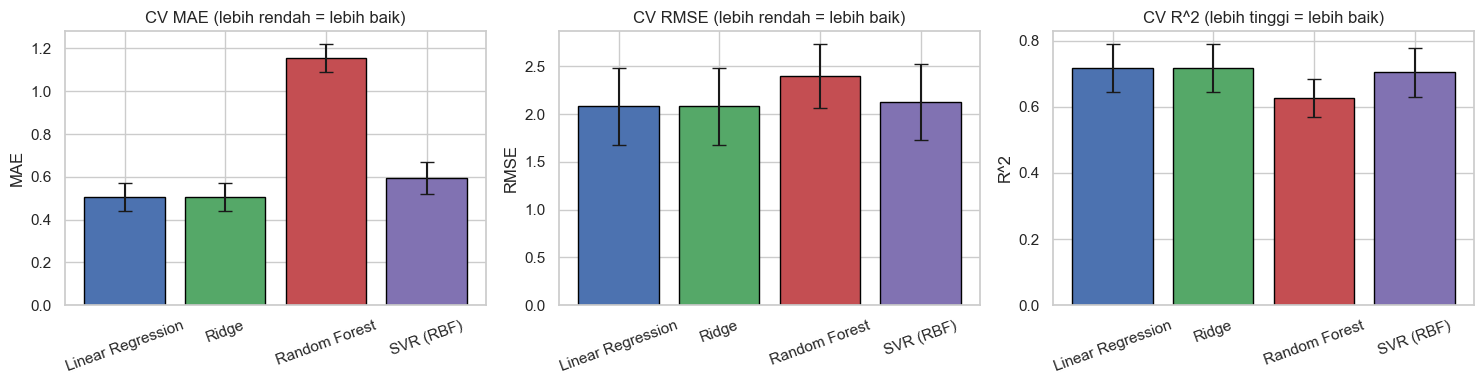

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_names = cv_df["Model"].tolist()
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

axes[0].bar(model_names, cv_df["CV MAE (mean)"], yerr=cv_df["CV MAE (std)"],
            color=colors, capsize=5, edgecolor="black")
axes[0].set_ylabel("MAE")
axes[0].set_title("CV MAE (lebih rendah = lebih baik)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(model_names, cv_df["CV RMSE (mean)"], yerr=cv_df["CV RMSE (std)"],
            color=colors, capsize=5, edgecolor="black")
axes[1].set_ylabel("RMSE")
axes[1].set_title("CV RMSE (lebih rendah = lebih baik)")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(model_names, cv_df["CV R2 (mean)"], yerr=cv_df["CV R2 (std)"],
            color=colors, capsize=5, edgecolor="black")
axes[2].set_ylabel("R^2")
axes[2].set_title("CV R^2 (lebih tinggi = lebih baik)")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_cv_comparison.png", bbox_inches="tight")
plt.show()

## 6. Tuning the settings

### 6.1 Tune Ridge

In [51]:
ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(random_state=RANDOM_STATE)),
])

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],
}

ridge_search = RandomizedSearchCV(
    ridge_pipe, ridge_param_grid, n_iter=7, cv=cv,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
ridge_search.fit(X_train, y_train)

print(f"Best Ridge alpha: {ridge_search.best_params_['model__alpha']}")
print(f"Best Ridge CV MAE: {-ridge_search.best_score_:.4f}")

Best Ridge alpha: 0.01
Best Ridge CV MAE: 0.5062


### 6.2 Tune Random Forest

In [52]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 15, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_grid, n_iter=8, cv=cv,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=2, verbose=0
)
rf_search.fit(X_train, y_train)

print(f"Best RF params: {rf_search.best_params_}")
print(f"Best RF CV MAE: {-rf_search.best_score_:.4f}")

Best RF params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 15}
Best RF CV MAE: 1.1350


### 6.3 Tune Support Vector Regression

In [53]:
svr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVR(kernel="rbf")),
])

svr_param_grid = {
    "model__C": [0.1, 1.0, 10.0],
    "model__epsilon": [0.1, 0.3, 0.5],
    "model__gamma": ["scale", "auto"],
}

svr_search = RandomizedSearchCV(
    svr_pipe, svr_param_grid, n_iter=6, cv=cv,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
svr_search.fit(X_train, y_train)

print(f"Best SVR params: {svr_search.best_params_}")
print(f"Best SVR CV MAE: {-svr_search.best_score_:.4f}")

Best SVR params: {'model__gamma': 'auto', 'model__epsilon': 0.1, 'model__C': 10.0}
Best SVR CV MAE: 0.5167


### 6.4 Keep the tuned versions

In [54]:
trained_pipelines["Ridge"] = ridge_search.best_estimator_
trained_pipelines["Random Forest"] = rf_search.best_estimator_
trained_pipelines["SVR (RBF)"] = svr_search.best_estimator_

print("Tuned pipelines registered:")
for name in trained_pipelines:
    print(f"  - {name}")

Tuned pipelines registered:
  - Linear Regression
  - Ridge
  - Random Forest
  - SVR (RBF)


## 6.5 Feature engineering experiment

In [55]:
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

interactions = {
    "Hours_x_Attendance":  ("Hours_Studied", "Attendance"),
    "Hours_x_Sleep":       ("Hours_Studied", "Sleep_Hours"),
    "Hours_x_PrevScores":  ("Hours_Studied", "Previous_Scores"),
}

for name, (a, b) in interactions.items():
    X_train_fe[name] = X_train_fe[a] * X_train_fe[b]
    X_test_fe[name]  = X_test_fe[a]  * X_test_fe[b]

print(f"Original features:       {X_train.shape[1]}")
print(f"With interactions:       {X_train_fe.shape[1]}")
print(f"New columns added:       {list(interactions.keys())}")

Original features:       19
With interactions:       22
New columns added:       ['Hours_x_Attendance', 'Hours_x_Sleep', 'Hours_x_PrevScores']


In [56]:
numeric_fe = numeric_features + list(interactions.keys())

preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_fe),
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ("nom", OneHotEncoder(drop="first", sparse_output=False), nominal_features),
    ],
    remainder="drop"
)

pipeline_fe = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", LinearRegression()),
])

result_fe = evaluate_cv(pipeline_fe, X_train_fe, y_train, cv, "LinReg + Interactions")

baseline = cv_df[cv_df["Model"] == "Linear Regression"].iloc[0]

print("=" * 70)
print("FEATURE ENGINEERING vs BASELINE  (5-fold CV on training set)")
print("=" * 70)
print(f"{'':30s} {'MAE':>10s} {'RMSE':>10s} {'R²':>10s}")
print(f"{'Baseline (19 features)':30s} "
      f"{baseline['CV MAE (mean)']:10.4f} "
      f"{baseline['CV RMSE (mean)']:10.4f} "
      f"{baseline['CV R2 (mean)']:10.4f}")
print(f"{'+ 3 interaction terms':30s} "
      f"{result_fe['CV MAE (mean)']:10.4f} "
      f"{result_fe['CV RMSE (mean)']:10.4f} "
      f"{result_fe['CV R2 (mean)']:10.4f}")

mae_diff = result_fe["CV MAE (mean)"] - baseline["CV MAE (mean)"]
r2_diff  = result_fe["CV R2 (mean)"]  - baseline["CV R2 (mean)"]
print(f"\nDifference:  MAE {mae_diff:+.4f},  R² {r2_diff:+.4f}")

FEATURE ENGINEERING vs BASELINE  (5-fold CV on training set)
                                      MAE       RMSE         R²
Baseline (19 features)             0.5062     2.0820     0.7171
+ 3 interaction terms              0.5109     2.0834     0.7167

Difference:  MAE +0.0047,  R² -0.0004


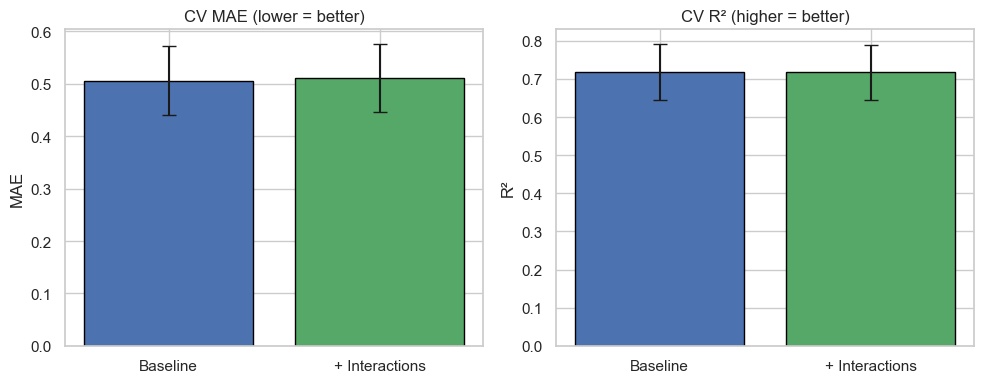

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

labels = ["Baseline", "+ Interactions"]
colors = ["#4C72B0", "#55A868"]

mae_vals = [baseline["CV MAE (mean)"], result_fe["CV MAE (mean)"]]
mae_errs = [baseline["CV MAE (std)"],  result_fe["CV MAE (std)"]]
axes[0].bar(labels, mae_vals, yerr=mae_errs, color=colors, capsize=5, edgecolor="black")
axes[0].set_ylabel("MAE")
axes[0].set_title("CV MAE (lower = better)")

r2_vals = [baseline["CV R2 (mean)"], result_fe["CV R2 (mean)"]]
r2_errs = [baseline["CV R2 (std)"],  result_fe["CV R2 (std)"]]
axes[1].bar(labels, r2_vals, yerr=r2_errs, color=colors, capsize=5, edgecolor="black")
axes[1].set_ylabel("R²")
axes[1].set_title("CV R² (higher = better)")

plt.tight_layout()
plt.savefig(FIG_DIR / "09_feature_engineering.png", bbox_inches="tight")
plt.show()

## 7. Final test

In [58]:
def adjusted_r2(r2, n, p):
    """Adjusted R^2: penalisasi untuk jumlah fitur."""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

test_results = []
n_test = len(y_test)
n_features = X_train_transformed.shape[1]

for name, pipeline in trained_pipelines.items():
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    adj_r2 = adjusted_r2(r2, n_test, n_features)

    test_results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted R2": adj_r2,
    })

test_df = pd.DataFrame(test_results).sort_values("MAE")
print("=" * 80)
print("HASIL EVALUASI PADA TEST SET")
print("=" * 80)
print(test_df.round(4).to_string(index=False))

best_model_name = test_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]
print(f"\n>>> Best model (by MAE): {best_model_name}")

HASIL EVALUASI PADA TEST SET
            Model    MAE    MSE   RMSE     R2  Adjusted R2
Linear Regression 0.4103 2.3038 1.5178 0.8258       0.8232
            Ridge 0.4103 2.3038 1.5178 0.8258       0.8232
        SVR (RBF) 0.4148 2.3425 1.5305 0.8229       0.8203
    Random Forest 1.0130 3.5868 1.8939 0.7288       0.7248

>>> Best model (by MAE): Linear Regression


### 7.2 Predicted vs actual

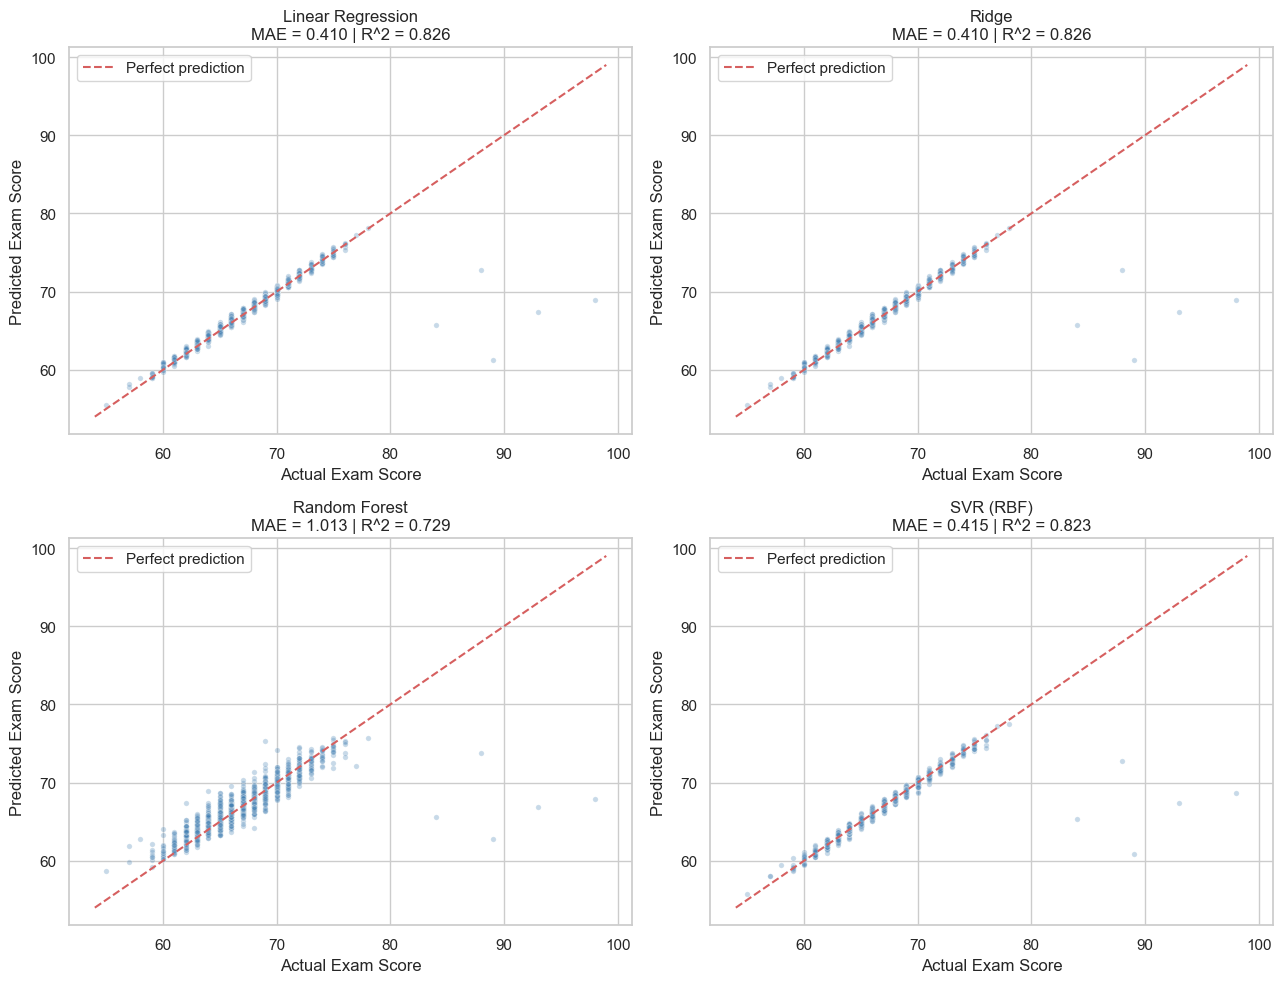

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for idx, (name, pipeline) in enumerate(trained_pipelines.items()):
    y_pred = pipeline.predict(X_test)
    ax = axes[idx]

    ax.scatter(y_test, y_pred, alpha=0.3, s=15, color="steelblue", edgecolor="white", linewidth=0.5)
    lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
    ax.set_xlabel("Actual Exam Score")
    ax.set_ylabel("Predicted Exam Score")

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f"{name}\nMAE = {mae:.3f} | R^2 = {r2:.3f}")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(FIG_DIR / "06_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

### 7.3 Leftover error

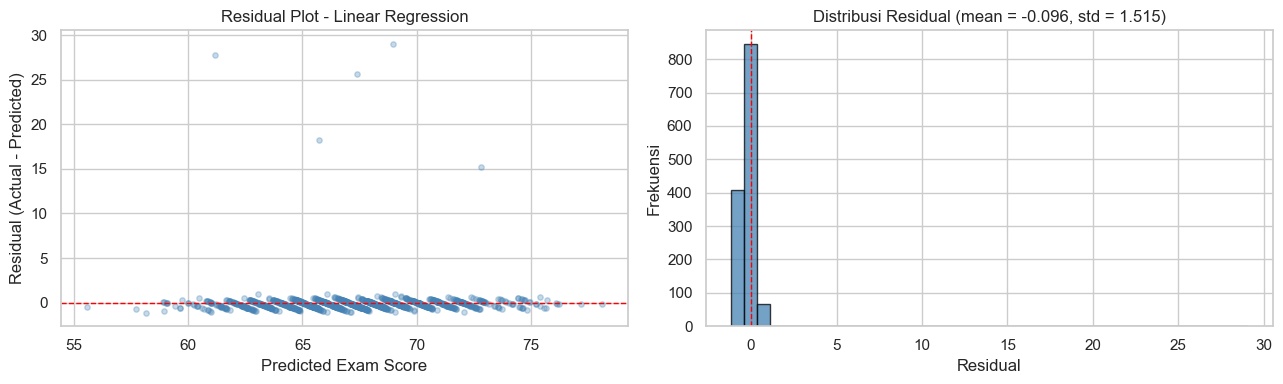

Residual stats:
  Mean:    -0.0961 (idealnya ~ 0)
  Std:     1.5153
  Min/Max: -1.15 / 29.04


In [60]:
y_pred_best = best_pipeline.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=15, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Predicted Exam Score")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title(f"Residual Plot - {best_model_name}")

axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="black", alpha=0.75)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frekuensi")
axes[1].set_title(f"Distribusi Residual (mean = {residuals.mean():.3f}, std = {residuals.std():.3f})")

plt.tight_layout()
plt.savefig(FIG_DIR / "07_residual_analysis.png", bbox_inches="tight")
plt.show()

print(f"Residual stats:")
print(f"  Mean:    {residuals.mean():.4f} (idealnya ~ 0)")
print(f"  Std:     {residuals.std():.4f}")
print(f"  Min/Max: {residuals.min():.2f} / {residuals.max():.2f}")

### 7.4 Which factors matter most

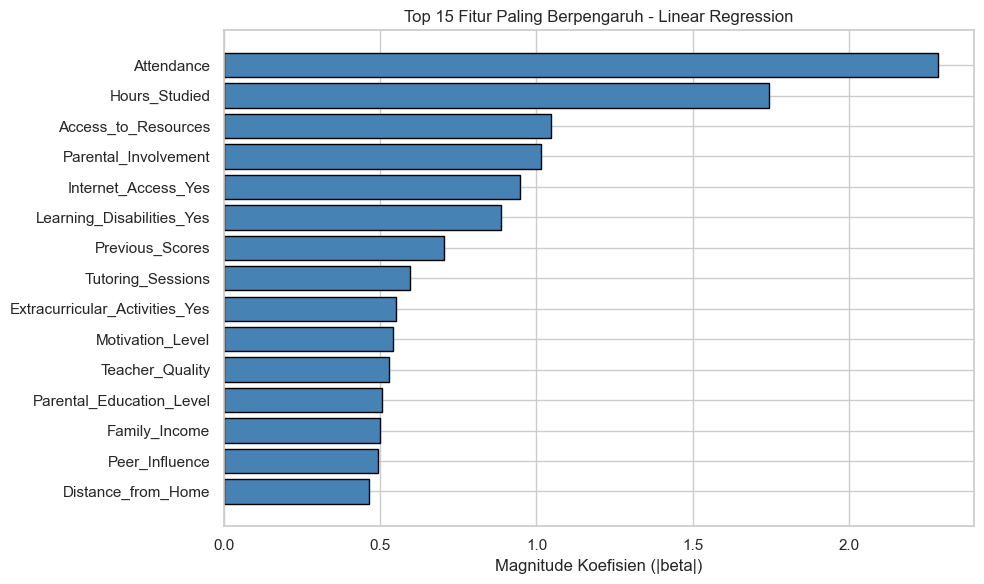


Top 10 fitur:
                         Fitur  Importance
                    Attendance    2.284560
                 Hours_Studied    1.742988
           Access_to_Resources    1.046299
          Parental_Involvement    1.015806
           Internet_Access_Yes    0.947342
     Learning_Disabilities_Yes    0.885075
               Previous_Scores    0.703901
             Tutoring_Sessions    0.595157
Extracurricular_Activities_Yes    0.550159
              Motivation_Level    0.540205


In [61]:
def get_feature_names(preprocessor, numeric, ordinal_cols, nominal_cols):
    """Reconstruct feature names setelah ColumnTransformer."""
    names = list(numeric) + list(ordinal_cols)
    ohe = preprocessor.named_transformers_["nom"]
    nominal_names = ohe.get_feature_names_out(nominal_cols).tolist()
    names.extend(nominal_names)
    return names

feature_names = get_feature_names(
    best_pipeline.named_steps["preprocessor"],
    numeric_features, ordinal_cols, nominal_features
)

model_obj = best_pipeline.named_steps["model"]

if hasattr(model_obj, "feature_importances_"):
    importance = model_obj.feature_importances_
    importance_type = "Feature Importance (Random Forest)"
elif hasattr(model_obj, "coef_"):
    importance = np.abs(model_obj.coef_)
    importance_type = "Magnitude Koefisien (|beta|)"
else:
    importance = None

if importance is not None:
    imp_df = pd.DataFrame({
        "Fitur": feature_names,
        "Importance": importance
    }).sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(imp_df["Fitur"][::-1], imp_df["Importance"][::-1], color="steelblue", edgecolor="black")
    plt.xlabel(importance_type)
    plt.title(f"Top 15 Fitur Paling Berpengaruh - {best_model_name}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "08_feature_importance.png", bbox_inches="tight")
    plt.show()

    print("\nTop 10 fitur:")
    print(imp_df.head(10).to_string(index=False))

### 7.5 Reading the Linear Regression

In [62]:
preprocessor_raw = ColumnTransformer(
    transformers=[
        ("num", FunctionTransformer(validate=False), numeric_features),
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        ("nom", OneHotEncoder(drop="first", sparse_output=False), nominal_features),
    ],
    remainder="drop"
)

linreg_raw = Pipeline([
    ("preprocessor", preprocessor_raw),
    ("model", LinearRegression()),
])
linreg_raw.fit(X_train, y_train)

raw_feature_names = get_feature_names(
    linreg_raw.named_steps["preprocessor"],
    numeric_features, ordinal_cols, nominal_features
)
raw_coefs = linreg_raw.named_steps["model"].coef_
intercept = linreg_raw.named_steps["model"].intercept_

coef_df = pd.DataFrame({
    "Fitur": raw_feature_names,
    "Koefisien (beta)": raw_coefs,
}).sort_values("Koefisien (beta)", key=abs, ascending=False)

print(f"Intercept (beta_0): {intercept:.4f}")
print(f"\nKoefisien lengkap (urut berdasarkan magnitude):")
print(coef_df.round(4).to_string(index=False))

Intercept (beta_0): 35.1307

Koefisien lengkap (urut berdasarkan magnitude):
                         Fitur  Koefisien (beta)
           Access_to_Resources            1.0463
          Parental_Involvement            1.0158
           Internet_Access_Yes            0.9473
     Learning_Disabilities_Yes           -0.8851
Extracurricular_Activities_Yes            0.5502
              Motivation_Level            0.5402
               Teacher_Quality            0.5276
      Parental_Education_Level            0.5065
                 Family_Income            0.5007
                Peer_Influence            0.4944
             Tutoring_Sessions            0.4828
            Distance_from_Home           -0.4634
                 Hours_Studied            0.2921
                    Attendance            0.1981
             Physical_Activity            0.1732
               Previous_Scores            0.0490
                   Gender_Male           -0.0148
            School_Type_Public           

In [63]:
print("=" * 80)
print("INTERPRETASI: 'Tiap +1 unit fitur X -> prediksi nilai naik beta poin'")
print("=" * 80)
top5 = coef_df.head(5)
for _, row in top5.iterrows():
    direction = "naik" if row["Koefisien (beta)"] > 0 else "turun"
    sign = "+" if row["Koefisien (beta)"] > 0 else ""
    print(f"  - {row['Fitur']}: tiap +1 unit -> nilai {direction} {sign}{row['Koefisien (beta)']:.4f} poin")

INTERPRETASI: 'Tiap +1 unit fitur X -> prediksi nilai naik beta poin'
  - Access_to_Resources: tiap +1 unit -> nilai naik +1.0463 poin
  - Parental_Involvement: tiap +1 unit -> nilai naik +1.0158 poin
  - Internet_Access_Yes: tiap +1 unit -> nilai naik +0.9473 poin
  - Learning_Disabilities_Yes: tiap +1 unit -> nilai turun -0.8851 poin
  - Extracurricular_Activities_Yes: tiap +1 unit -> nilai naik +0.5502 poin


## 8. Save the model

In [64]:
model_path = OUTPUT_DIR / "best_model.joblib"
joblib.dump(best_pipeline, model_path)
print(f"Saved: {model_path}")

metadata = {
    "best_model": best_model_name,
    "test_metrics": test_df[test_df["Model"] == best_model_name].iloc[0].to_dict(),
    "feature_schema": {
        "numeric": {
            col: {
                "min": float(df_clean[col].min()),
                "max": float(df_clean[col].max()),
                "mean": float(df_clean[col].mean()),
                "median": float(df_clean[col].median()),
            } for col in numeric_features
        },
        "ordinal": ordinal_features,
        "nominal": {col: sorted(df_clean[col].dropna().unique().tolist()) for col in nominal_features},
    },
    "target": "Exam_Score",
    "target_range": [int(df_clean["Exam_Score"].min()), int(df_clean["Exam_Score"].max())],
}

def to_native(obj):
    if isinstance(obj, dict):
        return {k: to_native(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_native(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

metadata = to_native(metadata)

with open(OUTPUT_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved: {OUTPUT_DIR / 'model_metadata.json'}")

cv_df.to_csv(OUTPUT_DIR / "cv_results.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_results.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'cv_results.csv'}")
print(f"Saved: {OUTPUT_DIR / 'test_results.csv'}")

Saved: artifacts\best_model.joblib
Saved: artifacts\model_metadata.json
Saved: artifacts\cv_results.csv
Saved: artifacts\test_results.csv


### 8.1 Quick check

In [65]:
loaded_pipeline = joblib.load(OUTPUT_DIR / "best_model.joblib")

sample_high = pd.DataFrame([{
    "Hours_Studied": 25,
    "Attendance": 95,
    "Parental_Involvement": "High",
    "Access_to_Resources": "High",
    "Extracurricular_Activities": "Yes",
    "Sleep_Hours": 7,
    "Previous_Scores": 85,
    "Motivation_Level": "High",
    "Internet_Access": "Yes",
    "Tutoring_Sessions": 3,
    "Family_Income": "High",
    "Teacher_Quality": "High",
    "School_Type": "Private",
    "Peer_Influence": "Positive",
    "Physical_Activity": 4,
    "Learning_Disabilities": "No",
    "Parental_Education_Level": "Postgraduate",
    "Distance_from_Home": "Near",
    "Gender": "Male",
}])

sample_low = pd.DataFrame([{
    "Hours_Studied": 8,
    "Attendance": 60,
    "Parental_Involvement": "Low",
    "Access_to_Resources": "Low",
    "Extracurricular_Activities": "No",
    "Sleep_Hours": 5,
    "Previous_Scores": 55,
    "Motivation_Level": "Low",
    "Internet_Access": "No",
    "Tutoring_Sessions": 0,
    "Family_Income": "Low",
    "Teacher_Quality": "Low",
    "School_Type": "Public",
    "Peer_Influence": "Negative",
    "Physical_Activity": 1,
    "Learning_Disabilities": "Yes",
    "Parental_Education_Level": "High School",
    "Distance_from_Home": "Far",
    "Gender": "Female",
}])

pred_high = loaded_pipeline.predict(sample_high)[0]
pred_low = loaded_pipeline.predict(sample_low)[0]

print(f"Sample 'rajin + supportive':  Predicted Exam_Score = {pred_high:.2f}")
print(f"Sample 'struggling':           Predicted Exam_Score = {pred_low:.2f}")
print(f"\nSelisih prediksi: {pred_high - pred_low:.2f} poin")
print(f"Range realistis: {metadata['target_range']}")

Sample 'rajin + supportive':  Predicted Exam_Score = 78.25
Sample 'struggling':           Predicted Exam_Score = 50.38

Selisih prediksi: 27.87 poin
Range realistis: [55, 100]


## 9. What the results say

## 10. Limits and next steps

## 11. Summary